## Apply TTMs to Solar Power data

This notebooke demonstrates the usage of a pre-trained `TinyTimeMixer` model for several multivariate time series forecasting tasks. For details related to model architecture, refer to the [TTM paper](https://arxiv.org/pdf/2401.03955.pdf).

In this example, we will use a pre-trained TTM-512-96 model. That means the TTM model can take an input of 512 time points (`context_length`), and can forecast upto 96 time points (`forecast_length`) in the future. We will use the pre-trained TTM in two settings:
1. **Zero-shot**: The pre-trained TTM will be directly used to evaluate on the `test` split of the target data. Note that the TTM was NOT pre-trained on the target data.
2. **Few-shot**: The pre-trained TTM will be quickly fine-tuned on only 5% of the `train` split of the target data, and subsequently, evaluated on the `test` part of the target data.

Note: Alternatively, this notebook can be modified to try the TTM-1024-96 model.

Pre-trained TTM models will be fetched from the [Hugging Face TTM Model Repository](https://huggingface.co/ibm/TTM).

## Installation

In [1]:
# Clone the ibm/tsfm
#! git clone https://github.com/IBM/tsfm.git

In [2]:
# Change directory. Move inside the tsfm repo.
#%cd tsfm

In [3]:
# Do ls
#! ls

In [5]:
from IPython.display import display, HTML
display(HTML("<style>:root { --jp-notebook-max-width: 80% !important; }</style>"))

### TILDE-Q loss functions

In [5]:
import torch
#from . import soft_dtw
#from . import path_soft_dtw 

PI = 3.141592653589793

'''
def amp_loss(outputs, targets):
    #outputs = B, T, 1 --> B, 1, T
    B,_, T = outputs.shape
    fft_size = 1 << (2 * T - 1).bit_length()
    out_fourier = torch.fft.fft(outputs, fft_size, dim = -1)
    tgt_fourier = torch.fft.fft(targets, fft_size, dim = -1)

    out_norm = torch.norm(outputs, dim = -1, keepdim = True)
    tgt_norm = torch.norm(targets, dim = -1, keepdim = True)

    #calculate normalized auto correlation
    auto_corr = torch.fft.ifft(tgt_fourier * tgt_fourier.conj(), dim = -1).real
    auto_corr = torch.cat([auto_corr[...,-(T-1):], auto_corr[...,:T]], dim = -1)
    nac_tgt = auto_corr / (tgt_norm * tgt_norm)

    # calculate cross correlation
    cross_corr = torch.fft.ifft(tgt_fourier * out_fourier.conj(), dim = -1).real
    cross_corr = torch.cat([cross_corr[...,-(T-1):], cross_corr[...,:T]], dim = -1)
    nac_out = cross_corr / (tgt_norm * out_norm)
    
    loss = torch.mean(torch.abs(nac_tgt - nac_out))
    return loss


def ashift_loss(outputs, targets):
    B, _, T = outputs.shape
    return T * torch.mean(torch.abs(1 / T - torch.softmax(outputs - targets, dim = -1)))

def phase_loss(outputs, targets):
    B, _, T = outputs.shape
    out_fourier = torch.fft.fft(outputs, dim = -1)
    tgt_fourier = torch.fft.fft(targets, dim = -1)
    tgt_fourier_sq = (tgt_fourier.real ** 2 + tgt_fourier.imag ** 2)
    mask = (tgt_fourier_sq > (T)).float()
    topk_indices = tgt_fourier_sq.topk(k = int(T**0.5), dim = -1).indices
    mask = mask.scatter_(-1, topk_indices, 1.)
    mask[...,0] = 1.
    mask = torch.where(mask > 0, 1., 0.)
    mask = mask.bool()
    not_mask = (~mask).float()
    not_mask /= torch.mean(not_mask)
    out_fourier_sq = (torch.abs(out_fourier.real) + torch.abs(out_fourier.imag))
    zero_error = torch.abs(out_fourier) * not_mask
    zero_error = torch.where(torch.isnan(zero_error), torch.zeros_like(zero_error), zero_error)
    mask = mask.float()
    mask /= torch.mean(mask)
    ae = torch.abs(out_fourier - tgt_fourier) * mask
    ae = torch.where(torch.isnan(ae), torch.zeros_like(ae), ae)
    phase_loss = (torch.mean(zero_error) + torch.mean(ae)) / (T ** .5)
    return phase_loss

def tildeq_loss(outputs, targets, alpha = .5, gamma = .0, beta = .5):
    outputs = outputs.permute(0,2,1)
    targets = targets.permute(0,2,1)
    assert not torch.isnan(outputs).any(), "Nan value detected!"
    assert not torch.isinf(outputs).any(), "Inf value detected!"
    B,_, T = outputs.shape
    l_ashift = ashift_loss(outputs, targets)
    l_amp = amp_loss(outputs, targets)
    l_phase = phase_loss(outputs, targets)
    loss = alpha * l_ashift + (1 - alpha) * l_phase + gamma * l_amp

    assert loss == loss, "Loss Nan!"
    return loss, l_ashift, l_amp, l_phase   #, torch.nn.MSELoss(output, targets)
'''

## Imports

In [6]:
# Standard
import os
import math
import tempfile
import torch

# Third Party
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed
import numpy as np
import pandas as pd

# First Party
'''
from tsfm_public.models.tinytimemixer.utils import (
    count_parameters,
    plot_preds,
)
'''

from tsfm_public.toolkit.util import (
    count_parameters,
    #plot_preds,
)

# Local
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction
from tsfm_public.toolkit.callbacks import TrackingCallback

# loss functions
from iotfunctions.metrics import TILDEQ,TREND, tildeq_loss, trend_loss


import matplotlib.pyplot as plt

2025-04-12 18:01:37.252503: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744473697.301275 1188227 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744473697.315409 1188227 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-12 18:01:37.368692: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Important arguments

In [7]:
# Set seed for reproducibility
SEED = 42
set_seed(SEED)

# DATA ROOT PATH
# Make sure to download the target data (here ettm2) on the `DATA_ROOT_PATH` folder.
# ETT is available at: https://github.com/zhouhaoyi/ETDataset/tree/main
target_dataset = "ettm2"
DATA_ROOT_PATH = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm2.csv"

# Results dir
OUT_DIR = "ttm_finetuned_models/"

# TTM model branch
# Use main for 512-96 model
# Use "1024_96_v1" for 1024-96 model
TTM_MODEL_REVISION = "main"

# Forecasting parameters
context_length = 512
forecast_length = 96

fewshot_fraction = 0.05 # we just need 5% of the data for finetuning

## Data processing pipeline

### Different data
#### Solar inverter or B&V Pump data

In [8]:
import datetime as dt
def to_time(x):
    y = None
    try:
        y = dt.datetime.strptime(x, '%d/%m/%y %H:%M')
    except Exception as e:
        y = dt.datetime.strptime(x, '%d/%m/%Y %H:%M')
    return y

df_Solar = pd.read_csv('~/src/notebooks-attic/data/INV1A_data2.csv', index_col=False, parse_dates=['datetime'], dayfirst=True)

# and sort it by timestamp
to_time_vec = np.vectorize(lambda x: to_time(x))
time_arr = to_time_vec(df_Solar['datetime'].values)
df_Solar['datetime'] = time_arr
df_Solar = df_Solar.sort_values(by='datetime')
df_Solar = df_Solar.rename(columns={'datetime':'date'}).drop(columns=['ROWID'])
#df_solar['date'] = pd.to_datetime(df_solar['date'])
df_Solar = df_Solar.set_index('date').reset_index()

<Axes: xlabel='date'>

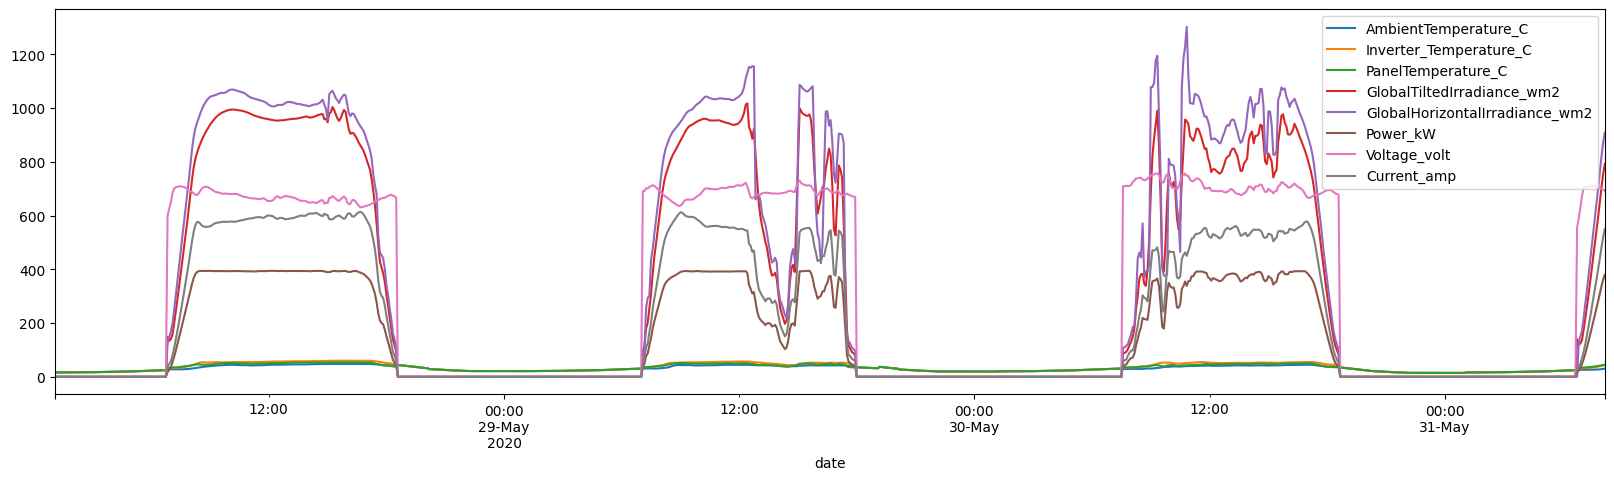

In [9]:
df_Solar[0:950].plot(x='date', figsize=(20,5))

In [10]:
#df_Solar = df_Solar.set_index('date')
#df_Solar = df_Solar.resample('5min').last().interpolate()
#df_Solar = df_Solar.reset_index()
df_Solar.describe()

,date,AmbientTemperature_C,Inverter_Temperature_C,PanelTemperature_C,GlobalTiltedIrradiance_wm2,GlobalHorizontalIrradiance_wm2,Power_kW,Voltage_volt,Current_amp
count,12528,12528.000000,12528.000000,12528.000000,12528.000000,12528.000000,12528.000000,12528.000000,12528.000000
mean,2020-06-18 19:02:30,36.492352,42.050112,39.144547,407.995105,433.980542,165.518382,341.942900,249.271326
min,2020-05-28 01:05:00,13.876353,13.876353,13.876353,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020-06-07 22:03:45,24.412819,25.817285,25.817285,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2020-06-18 19:02:30,37.648800,41.659668,39.034414,111.899414,122.943848,41.930908,608.078125,61.902588
75%,2020-06-29 16:01:15,45.542114,56.805420,51.000000,958.146484,1015.601563,389.274414,668.476562,570.925781
max,2020-07-10 13:00:00,67.000000,73.000000,69.564453,1213.953125,1302.406250,398.921875,784.773438,655.101562
std,NaN,12.824483,16.489779,13.810465,452.449640,478.599213,179.991000,333.937525,271.857981


<Axes: xlabel='date'>

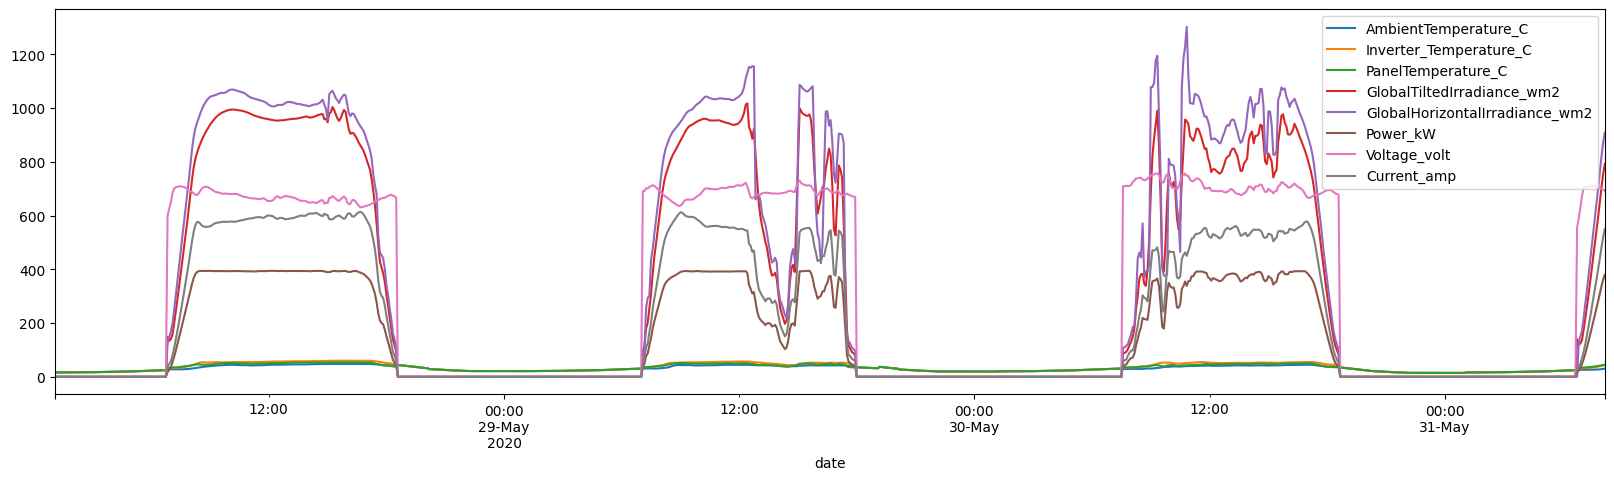

In [11]:

df_Solar[0:950].plot(x='date', figsize=(20,5))

In [12]:
#df_BV = df_BV.reset_index()
from sklearn.preprocessing import StandardScaler
stdscale = StandardScaler()
normalized_data = stdscale.fit_transform(df_Solar.set_index('date'))

df_solar = pd.DataFrame(normalized_data, columns=df_Solar.set_index('date').columns)
df_solar['date'] = df_Solar['date']

<Axes: xlabel='date'>

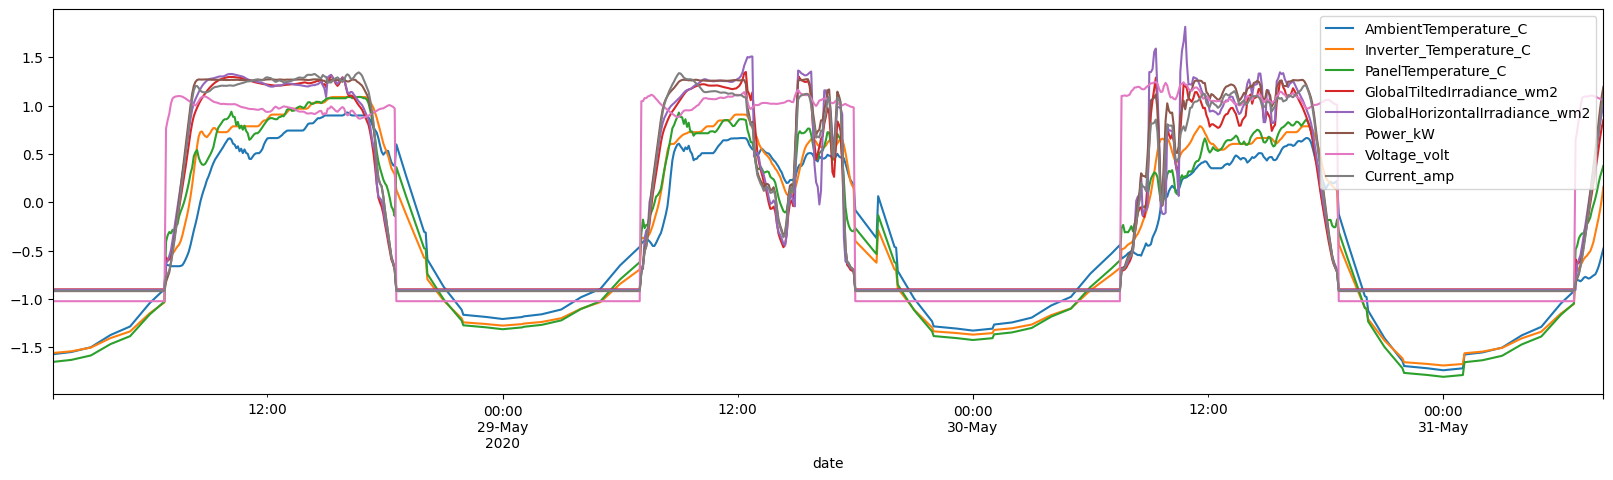

In [13]:

df_solar[0:950].plot(x='date', figsize=(20,5)) #(x="date", y="HUFL", figsize=(20,5))

#### Simplify - in the spirit of symbolic fourier approximation

In [14]:
from numpy.lib.stride_tricks import sliding_window_view
import scipy as sp

# apply only to regular features
cols = list(df_solar.columns)
cols.remove('date')

In [15]:
# FFT, cut off higher frequencies, IFFT
# Brute force, for the more elegant version refer to the aeon python library
length = 256
drop_coeff = 10

mult = np.array([sp.stats.norm.pdf(x) for x in range(length // 2 + 1)])

col_t = []
for col in cols:
    a_windows = sliding_window_view(df_solar[col].values, length)[::1, :]
    windows_list = []
    for i in range(a_windows.shape[0]):
        X_fft = sp.fft.rfft(a_windows[i])
        #X_fft = np.multiply(X_fft, mult)
        X_fft[drop_coeff:] = 0
        #X_fft[0] = 0
        el = sp.fft.irfft(X_fft) #[0:1]
        windows_list.append(el)
    wl = np.array(windows_list)    
    col_t.append(wl[:,0])

In [16]:
len(col_t[0])

12273

In [17]:
df_solar_sim = pd.DataFrame(data=np.array(col_t).T, columns=cols)
df_solar_sim['date'] = pd.to_datetime(df_solar['date'].values.flatten())[:len(df_solar_sim)]

<Axes: title={'center': 'Approximation'}, xlabel='date'>

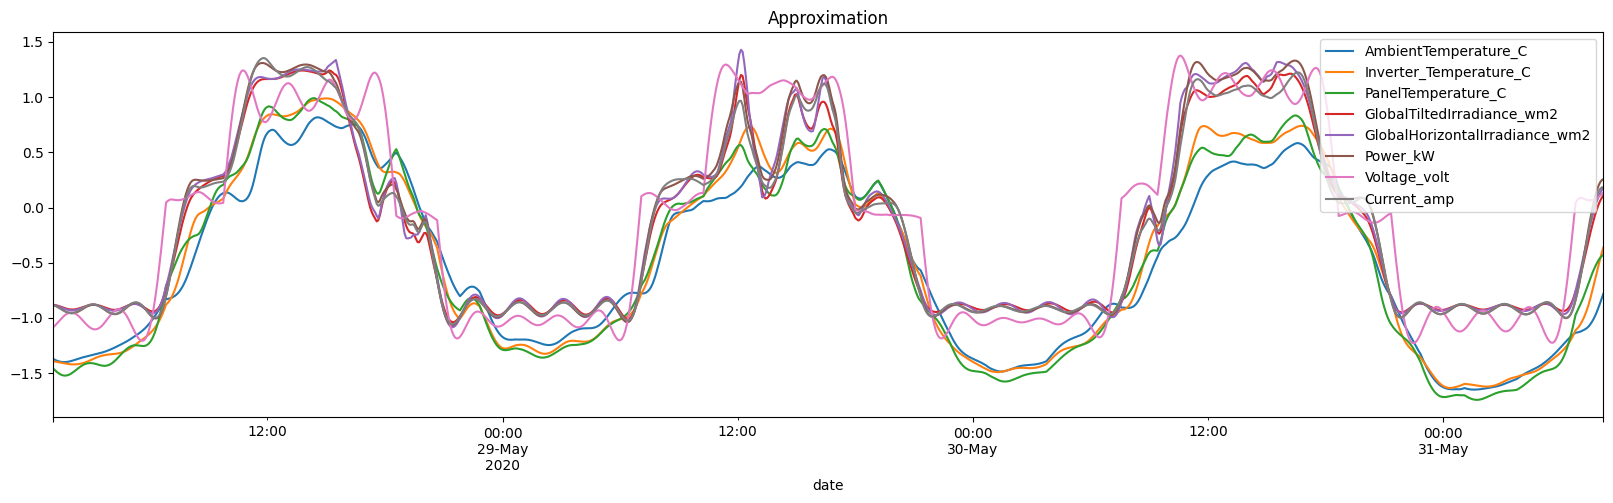

In [18]:
df_solar_sim[0:950].plot(x='date', figsize=(20,5), title='Approximation')

In [19]:
cols

['AmbientTemperature_C',
 'Inverter_Temperature_C',
 'PanelTemperature_C',
 'GlobalTiltedIrradiance_wm2',
 'GlobalHorizontalIrradiance_wm2',
 'Power_kW',
 'Voltage_volt',
 'Current_amp']

<Axes: >

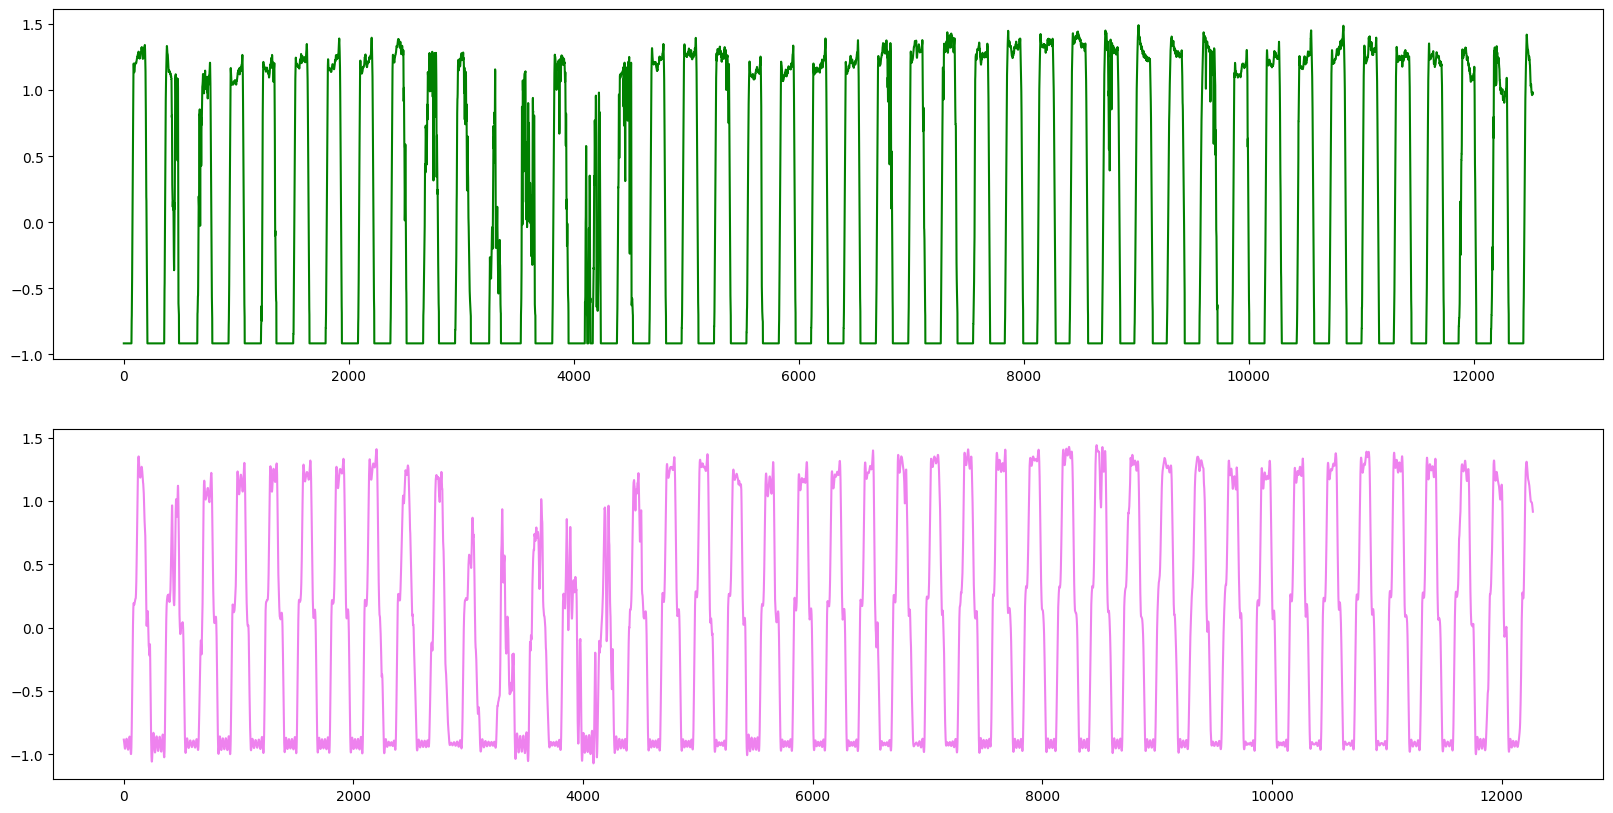

In [20]:
# Compare
colu = 'Current_amp'
fig,ax = plt.subplots(2,1,figsize=(20,10))
df_solar[colu].plot(ax=ax[0],c='g')
df_solar_sim[colu].plot(ax=ax[1],c='violet')


#### Zero-shot forecasting - Regular time-adjusted data

In [21]:
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor

train_end_index = 2000

dataset_path = DATA_ROOT_PATH
timestamp_column = "date"
id_columns = []
#target_columns = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]
target_columns = cols
split_config = {
                "train": 0.2,
                "validation" : 0.1,
                "test": 0.7
            }

data = df_solar.copy()

column_specifiers = {
    "timestamp_column": timestamp_column,
    "id_columns": id_columns,
    "target_columns": target_columns,
    "control_columns": [],
}

tsp = TimeSeriesPreprocessor(
    **column_specifiers,
    context_length=context_length,
    prediction_length=forecast_length,
    scaling=True,
    encode_categorical=False,
    freq = "0 days 01:00:00",
    scaler_type="standard",
)

fewshot_fraction = 1.0

train_dataset, valid_dataset, test_dataset = tsp.get_datasets(
    data, split_config, fewshot_fraction=fewshot_fraction, fewshot_location="first"
)
print(f"Data lengths: train = {len(train_dataset)}, val = {len(valid_dataset)}, test = {len(test_dataset)}")

Data lengths: train = 1898, val = 1159, test = 8674


/tmp/ipykernel_1188227/4056683568.py:37: DeprecationWarning: Call to deprecated method get_datasets. (Please use the standalone function `get_datasets()`.) -- Deprecated since version 0.1.1.
  train_dataset, valid_dataset, test_dataset = tsp.get_datasets(


In [22]:
test_dataset.datasets[0].prediction_length  #just to make sure ;-)

96

In [24]:
#zeroshot_model = TinyTimeMixerForPrediction.from_pretrained("ibm/TTM", revision=TTM_MODEL_REVISION)
zeroshot_model = TinyTimeMixerForPrediction.from_pretrained("/home/markus/Downloads/ttm", revision=TTM_MODEL_REVISION, use_safetensors=True)
#zeroshot_model

In [25]:
temp_dir = tempfile.mkdtemp()
# zeroshot_trainer
zeroshot_trainer = Trainer(
    model=zeroshot_model,
    args=TrainingArguments(
        output_dir=temp_dir,
        per_device_eval_batch_size=64,
        skip_memory_metrics=False,
    )
)

/home/markus/.local/lib/python3.12/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [26]:
zeroshot_trainer.evaluate(test_dataset)

{'eval_loss': 0.9593732357025146,
 'eval_model_preparation_time': 0.0099,
 'eval_runtime': 49.4243,
 'eval_samples_per_second': 175.501,
 'eval_steps_per_second': 2.752,
 'init_mem_cpu_alloc_delta': 1347584,
 'init_mem_cpu_peaked_delta': 0,
 'eval_mem_cpu_alloc_delta': 83738624,
 'eval_mem_cpu_peaked_delta': 26038272,
 'before_init_mem_cpu': 1480974336}

In [23]:
#test_dataset[8673]

In [24]:
#zeroshot_model(my_samples[0:1,:,:])['prediction_outputs'].shape

In [23]:
# move by steps of 96
my_samples = torch.stack([test_dataset[i]['past_values'] for i in range(0, 8673, 96)]) # range(0,8673, 96)
y = torch.stack([test_dataset[i]['future_values'] for i in range(0, 8673, 96)])

output = zeroshot_trainer.model(my_samples)
y_hat = output.prediction_outputs[:, :, :]  #.detach().cpu().numpy()
#y = "future_values"][:pred_len, channel]
#y = 
y_hat.shape, y.shape
#test_dataset[0]['future_values'].shape

(torch.Size([91, 96, 8]), torch.Size([91, 96, 8]))

In [24]:
y[:,:,0:1].shape

torch.Size([91, 96, 1])

In [25]:
import torch.nn as nn

loss = nn.MSELoss()
#loss(y[:,:,1], y_hat[:,:,1]), ashift_loss(y, y_hat), amp_loss(y, y_hat), phase_loss(y[:,:,0:2], y_hat[:,:,0:2]).item()
tildeq_loss(y[:,:,0:1], y_hat[:,:,0:1]), loss(y[:,:,0:1], y_hat[:,:,0:1])


((tensor(1.3522, grad_fn=<AddBackward0>),
  tensor(0.4578, grad_fn=<MulBackward0>),
  tensor(0.3832, grad_fn=<MeanBackward0>),
  tensor(2.2466, grad_fn=<DivBackward0>)),
 tensor(1.3980, grad_fn=<MseLossBackward0>))

### CAVEAT

Run finetune_forecast a couple of cells below first !!!!

In [33]:
# CAVEAT: Run finetune_forecast first !!!!
j = 0
my_samples = torch.stack([test_dataset[i]['past_values'] for i in range(0, 8673, 96)])
output = zeroshot_trainer.model(my_samples)
output_fine = finetune_forecast_trainer.model(my_samples)

yT = torch.stack([test_dataset[i]['future_values'] for i in range(0, 8673, 96)])
y_hatT = output.prediction_outputs
y_fineT = output_fine.prediction_outputs
y_hat = output.prediction_outputs[:, :, :].detach().cpu().numpy()
y_fine = output_fine.prediction_outputs[:, :, :].detach().cpu().numpy()


overall, shift, amp, phase = tildeq_loss(yT, y_hatT)
mseloss = torch.nn.MSELoss() 
mse = mseloss(yT.permute(0,2,1), y_hatT.permute(0,2,1))
print("Zeroshot Loss: MSE " + str(mse.item()) + ", Shift " + str(shift.item()) + ", AMP " + str(amp.item()) + ", Phase " + str(phase.item()))


overallf, shiftf, ampf, phasef = tildeq_loss(yT, y_fineT)
msef = mseloss(yT.permute(0,2,1), y_fineT.permute(0,2,1))
print("Finetune Loss: MSE " + str(msef.item()) + ", Shift " + str(shiftf.item()) + ", AMP " + str(ampf.item()) + ", Phase " + str(phasef.item()))


Zeroshot Loss: MSE 0.8725482821464539, Shift 0.3846181035041809, AMP 0.304521769285202, Phase 1.8432905673980713
Finetune Loss: MSE 0.10197827219963074, Shift 0.16537857055664062, AMP 0.05737758427858353, Phase 0.8228316307067871


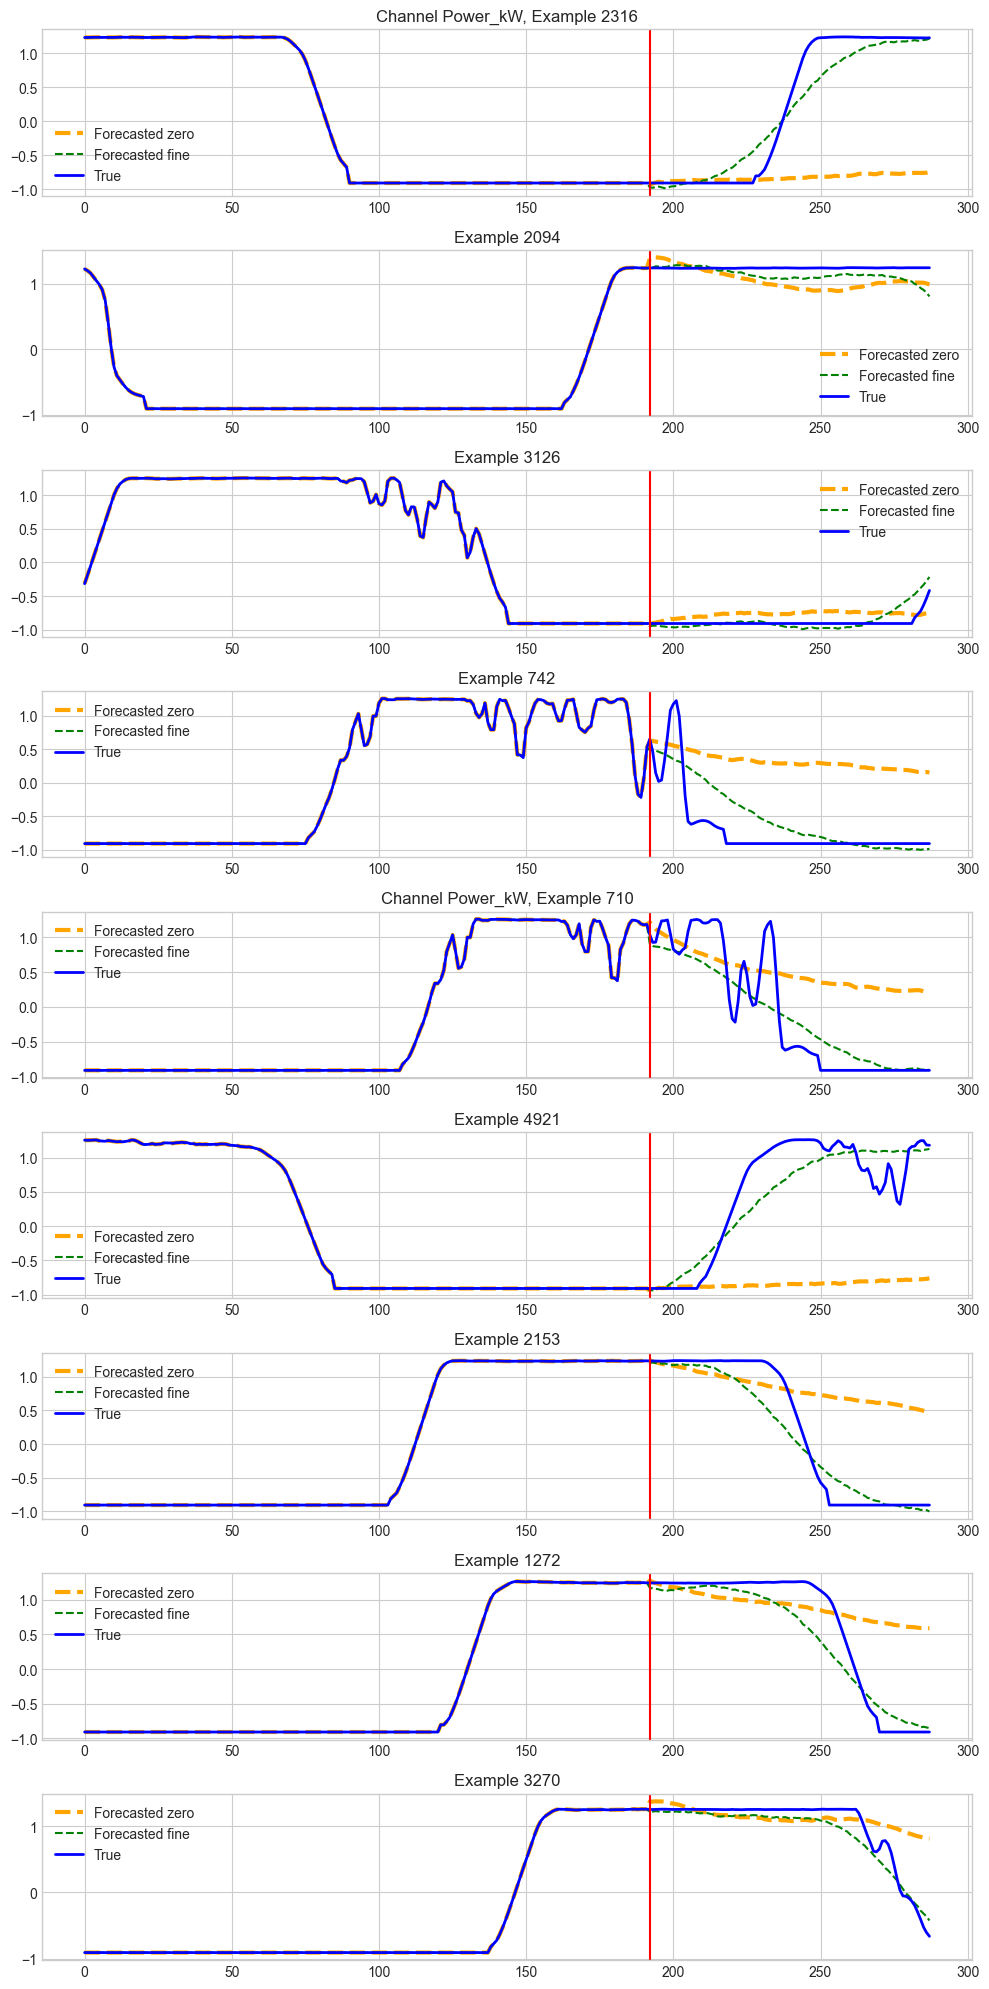

In [34]:
import torch.nn as nn
dset = test_dataset
channel = 5
truncate_history = True
index_list = [2316, 2094, 3126, 742, 710, 4921, 2153, 1272,3270]
my_samples = torch.stack([dset[i]["past_values"] for i in index_list])
#zeroshot_trainer.model = trainer.model.to(device)
output = zeroshot_trainer.model(my_samples)
output_fine = finetune_forecast_trainer.model(my_samples)

y_hatT = output.prediction_outputs[:, :, channel]
y_fineT = output_fine.prediction_outputs[:, :, channel]

y_hat = output.prediction_outputs[:, :, channel].detach().cpu().numpy()
y_fine = output_fine.prediction_outputs[:, :, channel].detach().cpu().numpy()
pred_len = y_hat.shape[1]

# Set a more beautiful style
plt.style.use("seaborn-v0_8-whitegrid")

# Adjust figure size and subplot spacing
fig, axs = plt.subplots(len(index_list), 1, figsize=(10, 20))

for i, ri in enumerate(index_list):
    batch = dset[ri]

    y = batch["future_values"][:pred_len, channel].squeeze().cpu().numpy()
    if truncate_history:
        x = batch["past_values"][-2 * pred_len :, channel].squeeze().cpu().numpy()
    else:
        x = batch["past_values"][:, channel].squeeze().cpu().numpy()
    y = np.concatenate((x, y), axis=0)

   

    # Plot predicted values with a dashed line
    y_hat_plot = np.concatenate((x, y_hat[i, ...]), axis=0)
    axs[i].plot(y_hat_plot, label="Forecasted zero", linestyle="--", color="orange", linewidth=3)

    # Plot predicted values with a dashed line
    y_fine_plot = np.concatenate((x, y_fine[i, ...]), axis=0)
    axs[i].plot(y_fine_plot, label="Forecasted fine", linestyle="--", color="green", linewidth=1.5)

    # Plot true values with a solid line
    axs[i].plot(y, label="True", linestyle="-", color="blue", linewidth=2)

    #yT = torch.unsqueeze(torch.unsqueeze(torch.from_numpy(y),1),1)
    #yhatT = torch.unsqueeze(torch.unsqueeze(torch.from_numpy(y_hat_plot),1),1)
    #print(yT.shape, yhatT.shape, ashift_loss(yT, yhatT))
    #MSE = torch.nn.MSELoss(yT, yhatT).item()
    #overall, shift, amp, phase, mse = tildeq_loss(yT, yhatT)
    #losses = "Loss: MSE " + str(mse) + ", Shift " + str(shift) + ", AMP " + str(amp) + ", Phase " + str(phase)
    #axs[i].plot([], [], ' ', label=losses)


    # Plot horizon border
    axs[i].axvline(x=2 * pred_len, color="r", linestyle="-")

    if i==0 or i==4:
        axs[i].set_title(f"Channel {cols[channel]}, Example {index_list[i]}")
    else:
        axs[i].set_title(f"Example {index_list[i]}")
    axs[i].legend()

# Adjust overall layout
plt.tight_layout()


In [29]:
# plot
#plot_preds(trainer=zeroshot_trainer, dset=test_dataset, plot_dir=os.path.join(OUT_DIR, "ettm2"), plot_prefix="test_zeroshot", channel=0)

 #### Few-shot finetune and evaluation method

In [70]:
# get another TTM instance
finetune_forecast_model = TinyTimeMixerForPrediction.from_pretrained("ibm/TTM", revision=TTM_MODEL_REVISION, head_dropout=0.7)
#finetune_forecast_model

#### Freeze the TTM backbone

In [71]:
print(
        "Number of params before freezing backbone",
        count_parameters(finetune_forecast_model),
    )

# Freeze the backbone of the model
for param in finetune_forecast_model.backbone.parameters():
    param.requires_grad = False

# Count params
print(
    "Number of params after freezing the backbone",
    count_parameters(finetune_forecast_model),
)

Number of params before freezing backbone 805280
Number of params after freezing the backbone 289696


#### Finetune few-shot 20%

In [72]:
# Important parameters
learning_rate = 0.001
num_epochs = 20 # Ideally, we need more epochs (try offline preferably in a gpu for faster computation)
batch_size = 64

In [73]:
print(f"Using learning rate = {learning_rate}")
finetune_forecast_args = TrainingArguments(
    output_dir=os.path.join(OUT_DIR, "output"),
    overwrite_output_dir=True,
    learning_rate=learning_rate,
    num_train_epochs=num_epochs,
    do_eval=True,
    evaluation_strategy="epoch",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    dataloader_num_workers=8,
    report_to=None,
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    logging_dir=os.path.join(OUT_DIR, "logs"),  # Make sure to specify a logging directory
    load_best_model_at_end=True,  # Load the best model when training ends
    metric_for_best_model="eval_loss",  # Metric to monitor for early stopping
    greater_is_better=False,  # For loss
    skip_memory_metrics=False,
)

# Create the early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=10,  # Number of epochs with no improvement after which to stop
    early_stopping_threshold=0.0,  # Minimum improvement required to consider as improvement
)
tracking_callback = TrackingCallback()

# Optimizer and scheduler
optimizer = AdamW(finetune_forecast_model.parameters(), lr=learning_rate)
scheduler = OneCycleLR(
    optimizer,
    learning_rate,
    epochs=num_epochs,
    steps_per_epoch=math.ceil(len(train_dataset) / (batch_size)),
)

finetune_forecast_trainer = Trainer(
    model=finetune_forecast_model,
    args=finetune_forecast_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    callbacks=[early_stopping_callback, tracking_callback],
    optimizers=(optimizer, scheduler),
)

# Fine tune
finetune_forecast_trainer.train()

Using learning rate = 0.001


/home/markus/.local/lib/python3.12/site-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,1.565300,0.567041
2,1.089800,0.367057
3,0.500200,0.182109
4,0.195200,0.154899
5,0.130600,0.149503
6,0.107900,0.150684
7,0.096700,0.153155
8,0.089200,0.152831
9,0.085600,0.154451
10,0.082100,0.153759


[TrackingCallback] Mean Epoch Time = 19.139622577031453 seconds, Total Train Time = 401.8193564414978


TrainOutput(global_step=450, training_loss=0.28828211784362795, metrics={'train_runtime': 400.9654, 'train_samples_per_second': 94.672, 'train_steps_per_second': 1.496, 'total_flos': 563437279641600.0, 'train_loss': 0.28828211784362795, 'init_mem_cpu_alloc_delta': 0, 'init_mem_cpu_peaked_delta': 0, 'train_mem_cpu_alloc_delta': 6955008, 'train_mem_cpu_peaked_delta': 3178496, 'before_init_mem_cpu': 2958733312, 'epoch': 15.0})

In [74]:
finetune_forecast_trainer.evaluate(test_dataset)

{'eval_loss': 0.09596817940473557,
 'eval_runtime': 45.4341,
 'eval_samples_per_second': 190.914,
 'eval_steps_per_second': 2.993,
 'epoch': 15.0,
 'eval_mem_cpu_alloc_delta': 0,
 'eval_mem_cpu_peaked_delta': 1499136}

In [32]:
#plot_preds(trainer=finetune_forecast_trainer, dset=test_dataset, 
#           plot_dir=os.path.join(OUT_DIR, "ettm2"), plot_prefix="test_zeroshot", channel=0)

### Zero-shot simplified data

NOT TRIED - OLD & STALE

In [83]:
train_end_index = 2000

dataset_path = DATA_ROOT_PATH
timestamp_column = "date"
id_columns = []
#target_columns = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]
target_columns = cols
split_config = {
                "train": 0.2,
                "validation" : 0.1,
                "test": 0.7
            }

data = df_solar_sim.copy()

column_specifiers = {
    "timestamp_column": timestamp_column,
    "id_columns": id_columns,
    "target_columns": target_columns,
    "control_columns": [],
}

tsp = TimeSeriesPreprocessor(
    **column_specifiers,
    context_length=context_length,
    prediction_length=forecast_length,
    scaling=True,
    encode_categorical=False,
    freq = "0 days 01:00:00",
    scaler_type="standard",
)

fewshot_fraction = 1.0

train_dataset, valid_dataset, test_dataset = tsp.get_datasets(
    data, split_config, fewshot_fraction=fewshot_fraction, fewshot_location="first"
)
print(f"Data lengths: train = {len(train_dataset)}, val = {len(valid_dataset)}, test = {len(test_dataset)}")

Data lengths: train = 1847, val = 1133, test = 8496


/tmp/ipykernel_1188227/2705958980.py:35: DeprecationWarning: Call to deprecated method get_datasets. (Please use the standalone function `get_datasets()`.) -- Deprecated since version 0.1.1.
  train_dataset, valid_dataset, test_dataset = tsp.get_datasets(


In [84]:
temp_dir = tempfile.mkdtemp()
# zeroshot_trainer
zeroshot_trainer_sim = Trainer(
    model=zeroshot_model,
    args=TrainingArguments(
        output_dir=temp_dir,
        per_device_eval_batch_size=64,
        skip_memory_metrics=False,
    )
)

In [85]:
zeroshot_trainer_sim.evaluate(test_dataset)

{'eval_loss': 0.87932950258255,
 'eval_model_preparation_time': 0.0139,
 'eval_runtime': 49.9604,
 'eval_samples_per_second': 170.055,
 'eval_steps_per_second': 2.662,
 'init_mem_cpu_alloc_delta': 0,
 'init_mem_cpu_peaked_delta': 0,
 'eval_mem_cpu_alloc_delta': 0,
 'eval_mem_cpu_peaked_delta': 0,
 'before_init_mem_cpu': 2970312704}

In [86]:
finetune_forecast_model_sim = TinyTimeMixerForPrediction.from_pretrained("ibm/TTM", revision=TTM_MODEL_REVISION, head_dropout=0.7)

# Freeze the backbone of the model
#for param in finetune_forecast_model.backbone.parameters():
#    param.requires_grad = False

# Important parameters
learning_rate = 0.001
num_epochs = 20 # Ideally, we need more epochs (try offline preferably in a gpu for faster computation)
batch_size = 64

In [87]:
finetune_forecast_args = TrainingArguments(
    output_dir=os.path.join(OUT_DIR, "output"),
    overwrite_output_dir=True,
    learning_rate=learning_rate,
    num_train_epochs=num_epochs,
    do_eval=True,
    evaluation_strategy="epoch",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    dataloader_num_workers=8,
    report_to=None,
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    logging_dir=os.path.join(OUT_DIR, "logs"),  # Make sure to specify a logging directory
    load_best_model_at_end=True,  # Load the best model when training ends
    metric_for_best_model="eval_loss",  # Metric to monitor for early stopping
    greater_is_better=False,  # For loss
    skip_memory_metrics=False,
)

# Create the early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=10,  # Number of epochs with no improvement after which to stop
    early_stopping_threshold=0.0,  # Minimum improvement required to consider as improvement
)
tracking_callback = TrackingCallback()

# Optimizer and scheduler
optimizer = AdamW(finetune_forecast_model_sim.parameters(), lr=learning_rate)
scheduler = OneCycleLR(
    optimizer,
    learning_rate,
    epochs=num_epochs,
    steps_per_epoch=math.ceil(len(train_dataset) / (batch_size)),
)

finetune_forecast_trainer_sim = Trainer(
    model=finetune_forecast_model_sim,
    args=finetune_forecast_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    callbacks=[early_stopping_callback, tracking_callback],
    optimizers=(optimizer, scheduler),
)

# Fine tune
finetune_forecast_trainer_sim.train()

/home/markus/.local/lib/python3.12/site-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,1.327300,0.321631
2,0.704600,0.154284
3,0.217000,0.123464
4,0.099500,0.112581
5,0.072300,0.106082
6,0.061600,0.105722
7,0.054600,0.100939
8,0.051000,0.096958
9,0.047000,0.098736
10,0.044600,0.094278


[TrackingCallback] Mean Epoch Time = 33.93175597190857 seconds, Total Train Time = 828.8679552078247


TrainOutput(global_step=580, training_loss=0.15305910973713316, metrics={'train_runtime': 828.0786, 'train_samples_per_second': 44.609, 'train_steps_per_second': 0.7, 'total_flos': 731063333683200.0, 'train_loss': 0.15305910973713316, 'init_mem_cpu_alloc_delta': 0, 'init_mem_cpu_peaked_delta': 0, 'train_mem_cpu_alloc_delta': 4481024, 'train_mem_cpu_peaked_delta': 3244032, 'before_init_mem_cpu': 2972147712, 'epoch': 20.0})

In [88]:
finetune_forecast_trainer_sim.evaluate(test_dataset)

{'eval_loss': 0.03600031137466431,
 'eval_runtime': 38.9201,
 'eval_samples_per_second': 218.293,
 'eval_steps_per_second': 3.417,
 'epoch': 20.0,
 'eval_mem_cpu_alloc_delta': 0,
 'eval_mem_cpu_peaked_delta': 1425408}

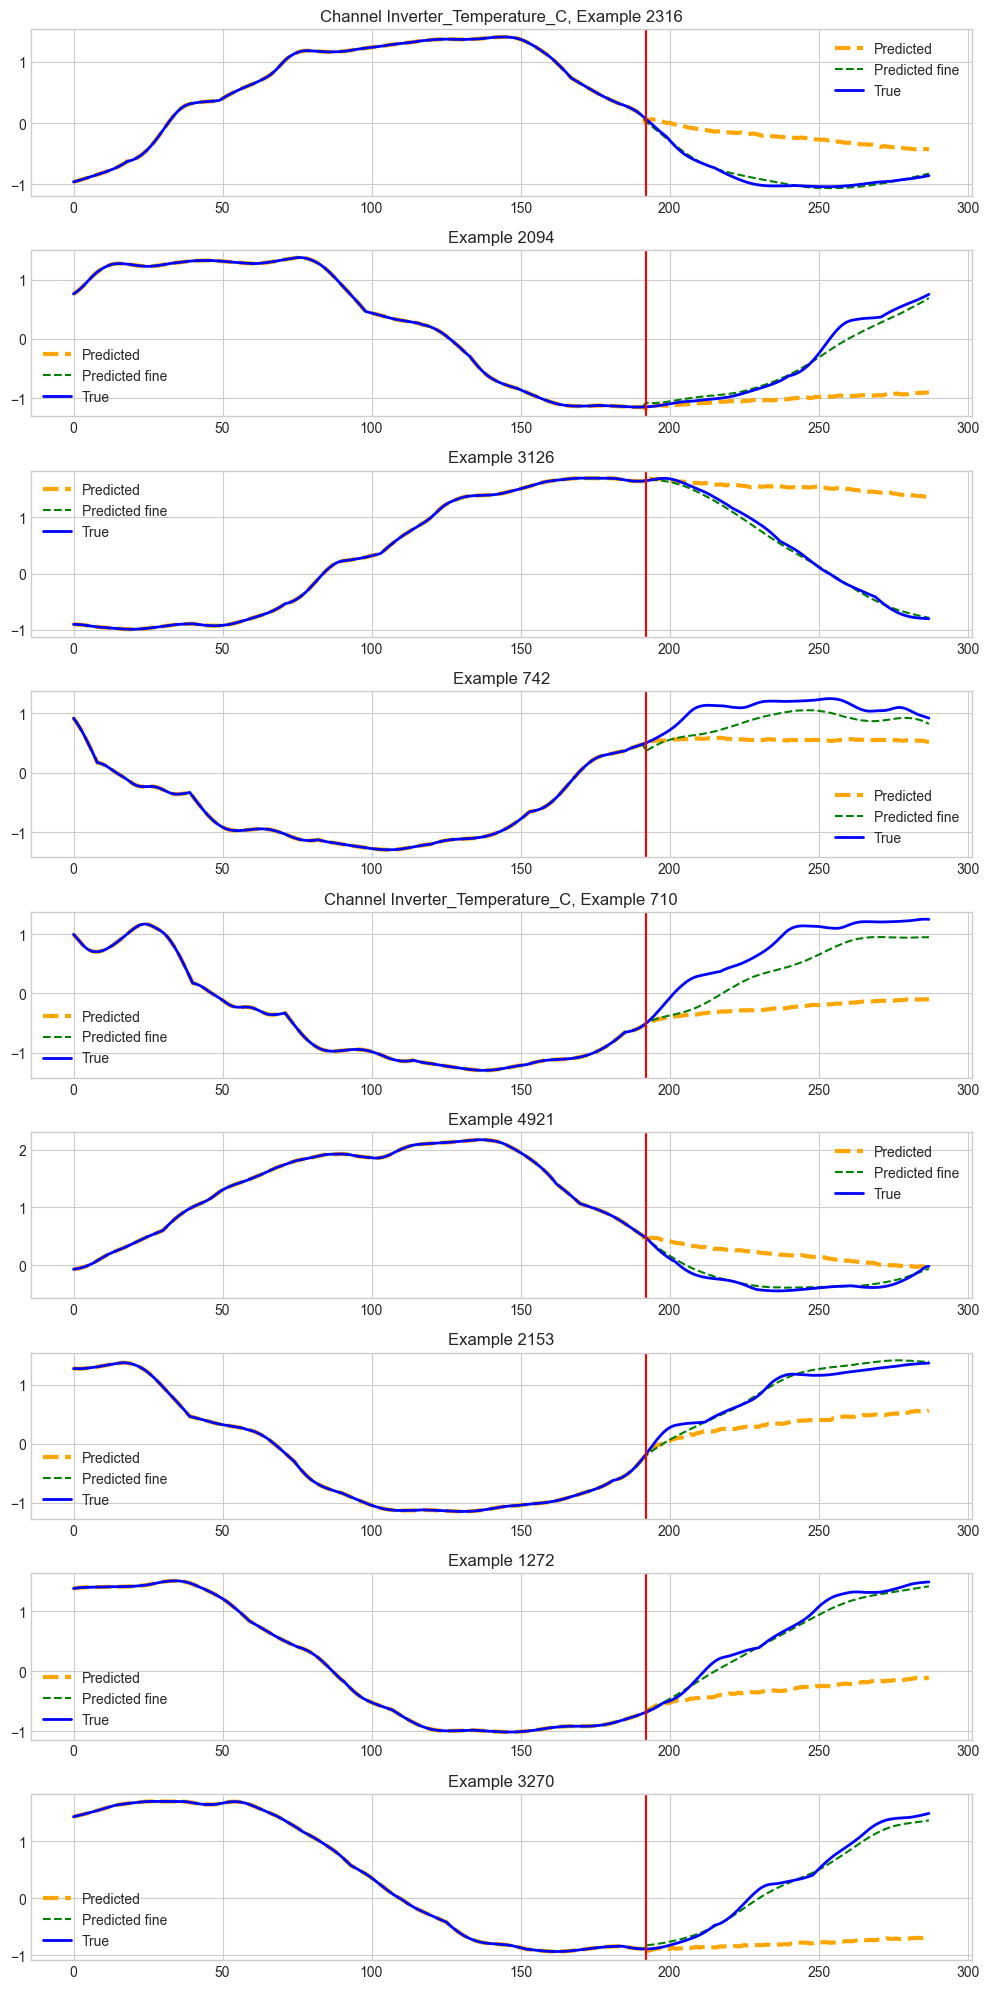

In [100]:
dset = test_dataset
channel = 1
truncate_history = True
index_list = [2316, 2094, 3126, 742, 710, 4921, 2153, 1272,3270]
my_samples = torch.stack([dset[i]["past_values"] for i in index_list])
#zeroshot_trainer.model = trainer.model.to(device)
output = zeroshot_trainer_sim.model(my_samples)
output_fine = finetune_forecast_trainer_sim.model(my_samples)

y_hat = output.prediction_outputs[:, :, channel].detach().cpu().numpy()
y_fine = output_fine.prediction_outputs[:, :, channel].detach().cpu().numpy()
pred_len = y_hat.shape[1]

# Set a more beautiful style
plt.style.use("seaborn-v0_8-whitegrid")

# Adjust figure size and subplot spacing
fig, axs = plt.subplots(len(index_list), 1, figsize=(10, 20))

for i, ri in enumerate(index_list):
    batch = dset[ri]

    y = batch["future_values"][:pred_len, channel].squeeze().cpu().numpy()
    if truncate_history:
        x = batch["past_values"][-2 * pred_len :, channel].squeeze().cpu().numpy()
    else:
        x = batch["past_values"][:, channel].squeeze().cpu().numpy()
    y = np.concatenate((x, y), axis=0)

    # Plot predicted values with a dashed line
    y_hat_plot = np.concatenate((x, y_hat[i, ...]), axis=0)
    axs[i].plot(y_hat_plot, label="Predicted", linestyle="--", color="orange", linewidth=3)

    # Plot predicted values with a dashed line
    y_fine_plot = np.concatenate((x, y_fine[i, ...]), axis=0)
    axs[i].plot(y_fine_plot, label="Predicted fine", linestyle="--", color="green", linewidth=1.5)

    # Plot true values with a solid line
    axs[i].plot(y, label="True", linestyle="-", color="blue", linewidth=2)

    # Plot horizon border
    axs[i].axvline(x=2 * pred_len, color="r", linestyle="-")

    if i==0 or i==4:
        axs[i].set_title(f"Channel {cols[channel]}, Example {index_list[i]}")
    else:
        axs[i].set_title(f"Example {index_list[i]}")
    axs[i].legend()

# Adjust overall layout
plt.tight_layout()

### Histograms

In [75]:
power_kw = torch.from_numpy(df_solar['Power_kW'].values).to(torch.float32)
univariate = power_kw
print(univariate)

tensor([-0.9196, -0.9196, -0.9196,  ...,  1.0408,  1.0387,  1.0322])


In [76]:
from tqdm import tqdm

channel = 1

mse_loss_zero = []
tildeq_loss_zero = []
trend_loss_zero = []

mse_loss_fine = []
tildeq_loss_fine = []
trend_loss_fine = []

past = []
future = []


for i in tqdm(range(len(univariate) - 512-96)):
    inputtensor = univariate[i:i+512].reshape(1,-1,1)
    future = univariate[i+512:i+512+96].reshape(1,-1)
    output_z = zeroshot_trainer.model(inputtensor).prediction_outputs.reshape(1,-1)
    output_f = finetune_forecast_trainer.model(inputtensor).prediction_outputs.reshape(1,-1)
    #print(inputtensor.shape, output_z.shape, future.shape)
    #output_z = zeroshot_trainer.model(tds['past_values'][None,:,:]).prediction_outputs[:,:,channel:channel+1]
    #future = tds['future_values'][:,channel].reshape(1,-1,1)
    #output_f = finetune_forecast_trainer(tds['past_values'][None,:,:])
    tl = tildeq_loss(output_z, future)
    tlf = tildeq_loss(output_f, future)
    tildeq_loss_zero.append(tl[0].detach().item())
    tildeq_loss_fine.append(tlf[0].detach().item())
    
tl, tlf

100%|█████████████████████████████████████████████████████████████████████████████████████████| 11920/11920 [09:16<00:00, 21.42it/s]


(tensor([2.1486], grad_fn=<AddBackward0>),
 tensor([0.7393], grad_fn=<AddBackward0>))

Text(0.5, 1.0, 'Few shot losses')

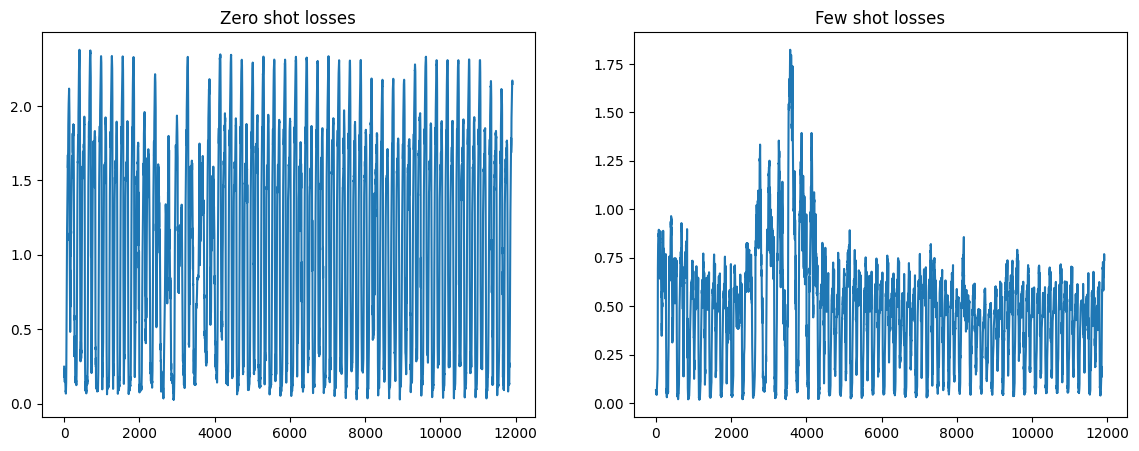

In [79]:
tildeq_loss_z = np.array(tildeq_loss_zero)
tildeq_loss_f = np.array(tildeq_loss_fine)
fig,ax = plt.subplots(1,2,figsize=(14,5))
ax[0].plot(tildeq_loss_z)
ax[0].set_title('Zero shot losses')
ax[1].plot(tildeq_loss_f)
ax[1].set_title('Few shot losses')

/home/markus/.local/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_1188227/3846736167.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
/home/markus/.local/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_1188227/3846736167.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


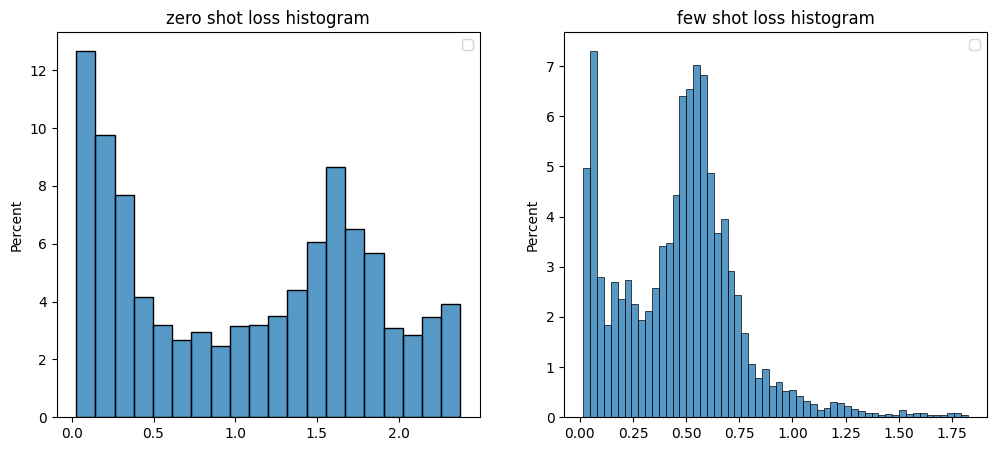

In [82]:
import seaborn as sns

fig,ax = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(tildeq_loss_z, stat='percent', ax=ax[0]) #, log_scale=True)
ax[0].set_title('zero shot loss histogram')
ax[0].legend()
sns.histplot(tildeq_loss_f, stat='percent', ax=ax[1]) #, log_scale=True)
ax[1].set_title('few shot loss histogram')
ax[1].legend()
#ax.set_ylim(0, 100)
#ax.plot((cutoff,cutoff), (0,30), c='r', label='anomaly cutoff')


### Same for low pass filtered data

In [89]:
power_kw_sim = torch.from_numpy(df_solar_sim['Power_kW'].values).to(torch.float32)
univariate_sim = power_kw_sim
print(univariate_sim)

tensor([-0.8843, -0.8889, -0.8952,  ...,  0.9882,  0.9774,  0.9671])


In [90]:
from tqdm import tqdm

channel = 1

#mse_loss_zero = []
tildeq_loss_sim_zero = []
#trend_loss_zero = []

#mse_loss_fine = []
tildeq_loss_sim_fine = []
#trend_loss_fine = []

for i in tqdm(range(len(univariate_sim) - 512-96)):
    inputtensor = univariate_sim[i:i+512].reshape(1,-1,1)
    future = univariate_sim[i+512:i+512+96].reshape(1,-1)
    output_z = zeroshot_trainer_sim.model(inputtensor).prediction_outputs.reshape(1,-1)
    output_f = finetune_forecast_trainer_sim.model(inputtensor).prediction_outputs.reshape(1,-1)
    
    tl = tildeq_loss(output_z, future)
    tlf = tildeq_loss(output_f, future)
    tildeq_loss_sim_zero.append(tl[0].detach().item())
    tildeq_loss_sim_fine.append(tlf[0].detach().item())
    
tl, tlf

100%|█████████████████████████████████████████████████████████████████████████████████████████| 11665/11665 [09:01<00:00, 21.53it/s]


(tensor([0.7218], grad_fn=<AddBackward0>),
 tensor([0.3037], grad_fn=<AddBackward0>))

In [91]:
tildeq_loss_sim_z = np.array(tildeq_loss_sim_zero)
tildeq_loss_sim_f = np.array(tildeq_loss_sim_fine)

/home/markus/.local/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_1188227/4082060532.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
/home/markus/.local/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_1188227/4082060532.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


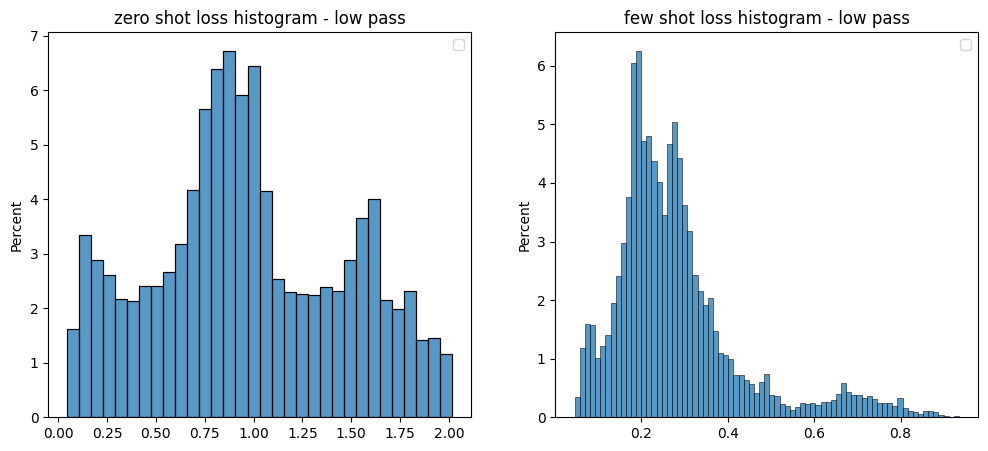

In [92]:
import seaborn as sns

fig,ax = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(tildeq_loss_sim_z, stat='percent', ax=ax[0]) #, log_scale=True)
ax[0].set_title('zero shot loss histogram - low pass')
ax[0].legend()
sns.histplot(tildeq_loss_sim_f, stat='percent', ax=ax[1]) #, log_scale=True)
ax[1].set_title('few shot loss histogram - low pass')
ax[1].legend()

### Left over

Stuff not used right now 

In [618]:
import logging
logging.basicConfig(level=50)
# workaround via specifying an invalid value first
%config Application.log_level='WORKAROUND'
# => fails, necessary on Fedora 27, ipython3 6.2.1
%config Application.log_level='DEBUG'
import logging
logging.getLogger().setLevel(logging.DEBUG)
log = logging.getLogger()
log.debug('Test debug')

[IPKernelApp] 
*** MESSAGE TYPE:execute_request***
[IPKernelApp]    Content: {'silent': False, 'store_history': True, 'user_expressions': {}, 'allow_stdin': True, 'stop_on_error': True, 'code': "import logging\nlogging.basicConfig(level=50)\n# workaround via specifying an invalid value first\n%config Application.log_level='WORKAROUND'\n# => fails, necessary on Fedora 27, ipython3 6.2.1\n%config Application.log_level='DEBUG'\nimport logging\nlogging.getLogger().setLevel(logging.DEBUG)\nlog = logging.getLogger()\nlog.debug('Test debug')"}
   --->
   
[IPKernelApp] execute_request: {'header': {'date': datetime.datetime(2024, 8, 1, 11, 52, 13, 169000, tzinfo=tzutc()), 'msg_id': 'fefe888f-d744-4e81-99f6-e489eb63c0a9', 'msg_type': 'execute_request', 'session': '3886830f-faf0-4391-aeba-c353b6da1a8b', 'username': '', 'version': '5.2'}, 'msg_id': 'fefe888f-d744-4e81-99f6-e489eb63c0a9', 'msg_type': 'execute_request', 'parent_header': {}, 'metadata': {'trusted': True, 'deletedCells': [], 'recordT

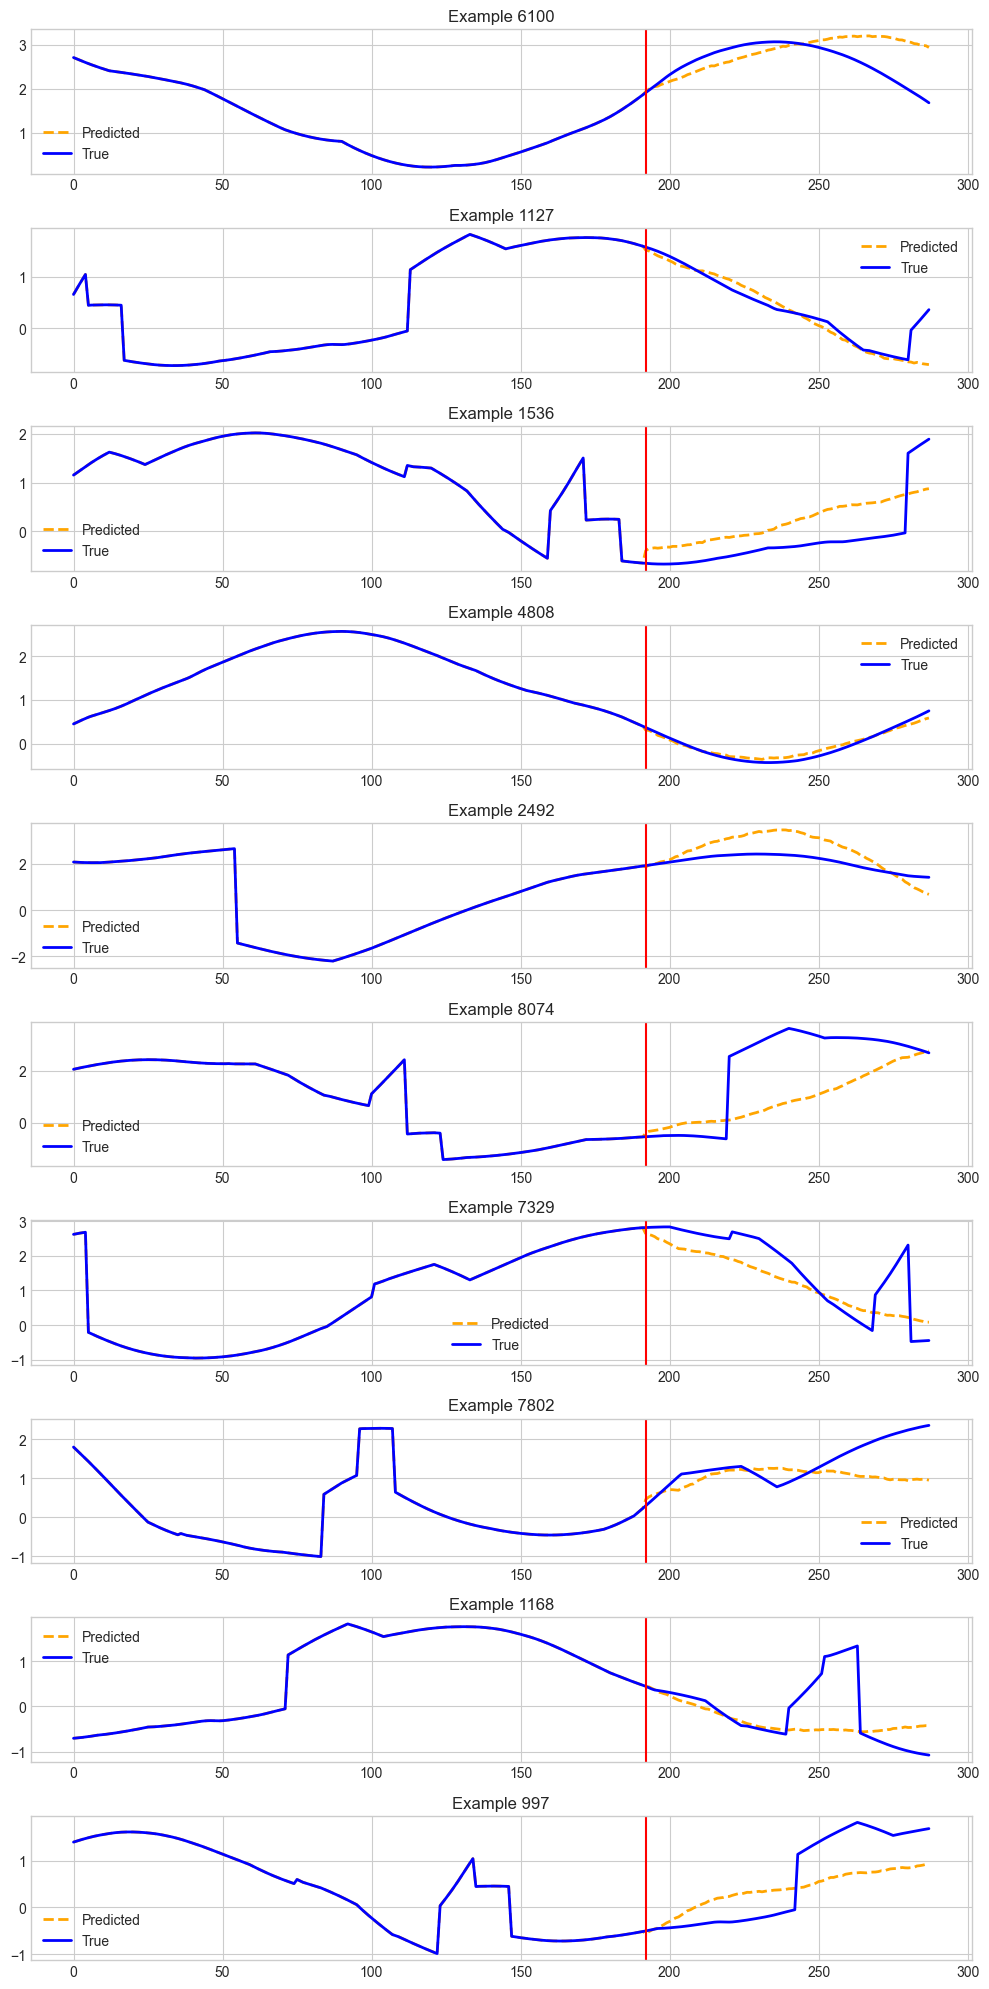

In [493]:
plot_preds(trainer=finetune_forecast_trainer, dset=test_dataset, plot_dir=os.path.join(OUT_DIR, "ettm2"), plot_prefix="test_fewshot", channel=0)

In [4]:
from IPython.display import display, HTML
display(HTML("<style>:root { --jp-notebook-max-width: 80% !important; }</style>"))